# Beam bending: Euler-Bernoulli and Timoshenko


Two beam theories, same cantilever benchmark. Euler-Bernoulli assumes cross
-sections stay perpendicular to the deflected centerline ($\theta = w'$); Timoshenko
drops that assumption and carries the rotation $\theta(x)$ as a second, independent
field.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import archimedes as arc
from archimedes.experimental.approximation import FunctionSpace
from archimedes.quadrature import composite_quad, gauss_legendre


## Euler-Bernoulli beam bending

$$EI\, u''''(x) = q(x), \qquad x \in [0, L]$$

the classical Euler-Bernoulli beam equation (with $EI=1$). This is a 4th-order
operator, and it needs $C^1$ continuity (value *and* slope shared between elements)
-- exactly what `CubicHermiteBasis` was built for
(`FunctionSpace.piecewise(kind="hermite", ..., continuity=1)`).

We use the classical cantilever beam under a tip load: clamped at $x=0$
($u(0)=u'(0)=0$) and free at $x=L$ with an applied tip shear ($u''(L)=0$, no applied
moment; $u'''(L)=P$, the tip shear) and no distributed load ($q=0$). The exact
solution is the textbook cubic $u(x) = \tfrac{P}{6}x^3 - \tfrac{PL}{2}x^2$ -- degree
3, so (unlike a quartic, which a piecewise-*cubic* space could only approximate)
it's exactly representable by piecewise cubic Hermite elements regardless of how
many elements there are, since a global cubic restricted to any sub-element is
still a cubic.

The weak form (two integrations by parts) is
$$\int_0^L u''\,v''\,dx = \int_0^L q\,v\,dx - \big[u'''v\big]_0^L + \big[u''v'\big]_0^L,$$
and since $v(0)=v'(0)=0$ (test functions satisfy the homogeneous clamped condition
too), only the $x=L$ terms survive: $-P\,v(L)$ (using $u'''(L)=P$, $u''(L)=0$,
$q=0$).

This is the first problem in this notebook to use `boundary_dofs(order=1)` -- the
slope DOF -- for a genuine essential condition (alongside `boundary_dofs(order=0)`
for the value), *and* a natural condition that lands on a single equation because
Hermite shape functions are cardinal at the nodes: only the right end's *value* DOF
is nonzero at $x=L$, so the tip load contributes to exactly one row.

(Migrated from `pde.ipynb`'s Problem D -- moved here to sit next to the Timoshenko
beam below, since the two problems are the same physical setup under two different
beam theories.)


In [2]:
L = 1.0
P = 6.0  # prescribed tip shear u'''(L)

breakpoints_eb = np.linspace(0.0, L, 5)  # 4 cubic Hermite elements
space_eb = FunctionSpace.piecewise("hermite", 3, breakpoints_eb, continuity=1)

left0, right0 = space_eb.basis.boundary_dofs(order=0)  # value DOFs
left1, right1 = space_eb.basis.boundary_dofs(order=1)  # slope DOFs
print(f"value DOFs: ({left0}, {right0}), slope DOFs: ({left1}, {right1})")


def u_exact_eb(x):
    return (P / 6) * x**3 - (P * L / 2) * x**2


d2Phi = space_eb.basis_matrix(deriv=2)
K_eb = d2Phi.T @ d2Phi  # stiffness matrix, int u'' v'' dx
u0_eb = space_eb.function()


def residual_eb(c):
    r = K_eb @ c

    # Natural BC: tip shear u'''(L) = P shows up only in the right end's
    # value-DOF row, since Hermite shape functions are cardinal at the nodes.
    r[right0] = r[right0] + P

    # Essential BCs: clamped at x=0 -- value *and* slope, both genuine DOF slots.
    r[left0] = c[left0] - 0.0
    r[left1] = c[left1] - 0.0
    return r


c0_eb = np.zeros(space_eb.n_basis)
c_sol_eb = arc.optimize.root(residual_eb, c0_eb)
u_sol_eb = u0_eb.replace(coefficients=c_sol_eb)

x_check_eb = np.linspace(0, L, 100)
err_eb = np.max(np.abs(u_sol_eb(x_check_eb) - u_exact_eb(x_check_eb)))
print(f"max |u_h - u_exact| on check grid: {err_eb:.3e}")


value DOFs: (0, 8), slope DOFs: (1, 9)
max |u_h - u_exact| on check grid: 9.481e-14


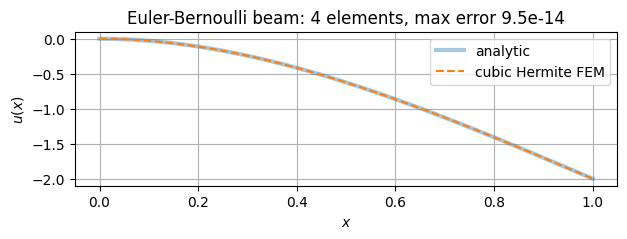

In [3]:
x_plot_eb = np.linspace(0, L, 200)

fig, ax = plt.subplots(1, 1, figsize=(7, 2))
ax.plot(x_plot_eb, u_exact_eb(x_plot_eb), lw=3, alpha=0.4, label="analytic")
ax.plot(x_plot_eb, u_sol_eb(x_plot_eb), "--", label="cubic Hermite FEM")
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x)$")
ax.set_title(
    f"Euler-Bernoulli beam: {space_eb.basis.n_elements} elements, "
    f"max error {err_eb:.1e}"
)
ax.grid()
ax.legend()
plt.show()


## Timoshenko beam bending

Euler-Bernoulli assumes cross-sections stay perpendicular to the deflected
centerline, $\theta = w'$. Timoshenko beam theory drops that assumption: the
rotation $\theta(x)$ becomes a second, independent field, and $\gamma = w' -
\theta$ is the (through-thickness-constant) shear strain. The two governing
equations are moment and shear equilibrium,

$$
\big(EI\,\theta'\big)' = \kappa GA\,(w' - \theta), \qquad
\big(\kappa GA\,(w' - \theta)\big)' = -q(x),
$$

where $\kappa GA$ is the shear stiffness ($\kappa$ the shear correction factor, $G$
the shear modulus, $A$ the cross-sectional area) and $EI$ the bending stiffness as
before. Equivalently, minimizing the total potential energy
$$
\Pi[w,\theta] = \frac12\int_0^L \Big[EI(\theta')^2 + \kappa GA(w'-\theta)^2\Big]\,dx
- \int_0^L q\,w\,dx - P\,w(L)
$$
gives the weak form

$$
\int_0^L EI\,\theta' v_\theta'\,dx - \int_0^L \kappa GA\,(w'-\theta)\,v_\theta\,dx = 0,
\qquad
\int_0^L \kappa GA\,(w'-\theta)\,v_w'\,dx = \int_0^L q\,v_w\,dx + P\,v_w(L),
$$

for independent test functions $v_w$, $v_\theta$ -- a genuinely *coupled*, two-field
problem. We represent $(w, \theta)$ as the two components of a single vector-valued
`Function` (coefficients shape `(n_basis, 2)`) with **independent boundary
conditions per component** -- the "coupled/vector-valued system" flagged as
untested in `pde.ipynb`'s further-test-problems list, and 2D row-splicing
(`(dof, component)` pairs) for essential BCs rather than the 1D case every other
problem so far has needed.

Same cantilever setup as above ($EI=1$, clamped at $x=0$, tip shear $P$ at $x=L$, no
distributed load) so the two beam theories are directly comparable. The beam is
statically determinate, so the shear force $\kappa GA(w'-\theta) = P$ and moment
$EI\theta' = P(L-x)$ are known from statics alone, independent of the kinematic
assumption; integrating twice with $w(0)=\theta(0)=0$ gives the exact solution

$$
\theta(x) = \frac{P}{EI}\Big(Lx - \frac{x^2}{2}\Big), \qquad
w(x) = \underbrace{\frac{P}{EI}\Big(\frac{Lx^2}{2} - \frac{x^3}{6}\Big)}_{\text{Euler-Bernoulli deflection}}
+ \underbrace{\frac{Px}{\kappa GA}}_{\text{shear correction}}.
$$

The bending part of $w$ is exactly $-u_\text{exact,eb}(x)$ from above (opposite sign
convention for $P$'s direction between the two sections), and as $\kappa GA \to
\infty$ the shear term vanishes -- the two beam theories agree in the thin-beam
limit, as they should.

We deliberately pick the discretization known to cause trouble: **equal-order,
linear ($C^0$ Lagrange) elements for both fields**, sharing one `FunctionSpace`,
integrated with the space's default ("full", 2-point Gauss per element)
quadrature. Away from the thin-beam limit this is a perfectly ordinary FEM
discretization; the failure mode below only shows up as $\kappa GA/EI$ grows large
relative to $1/L^2$ -- a slender beam, shear deformation negligible, exactly the
regime that reduces to Euler-Bernoulli.


In [4]:
def theta_exact_ts(x, P=P, L=L, EI=1.0):
    return (P / EI) * (L * x - x**2 / 2)


def w_exact_ts(x, kappaGA, P=P, L=L, EI=1.0):
    return (P / EI) * (L * x**2 / 2 - x**3 / 6) + P * x / kappaGA


def assemble_timoshenko(n_elements, kappaGA, reduced_shear=False, P=P, L=L, EI=1.0):
    """Cantilever Timoshenko beam under a tip shear P: linear C0 elements for
    both w (component 0) and theta (component 1), sharing one FunctionSpace.

    ``reduced_shear=True`` uses a 1-point-per-element quadrature rule for the
    shear terms only (selective reduced integration); bending is always
    integrated with the space's default (exact, for linear elements) rule.
    """
    breakpoints = np.linspace(0.0, L, n_elements + 1)
    space = FunctionSpace.piecewise("lagrange", 1, breakpoints)
    n_basis = space.n_basis
    left, right = space.basis.boundary_dofs()

    Phi = space.basis_matrix()
    dPhi = space.basis_matrix(deriv=1)

    if reduced_shear:
        # One-point Gauss per element (vs. the default 2-point rule) --
        # under-integrates the shear term just enough to relieve locking.
        reduced_rule = composite_quad(
            gauss_legendre(1), space.basis.breakpoints
        ).map_to(a=0.0, b=L)
        Phi_s = space.basis_matrix(quad_rule=reduced_rule)
        dPhi_s = space.basis_matrix(deriv=1, quad_rule=reduced_rule)
    else:
        Phi_s, dPhi_s = Phi, dPhi

    K_bend = EI * (dPhi.T @ dPhi.matrix)  # theta-theta bending block
    K_ww = kappaGA * (dPhi_s.T @ dPhi_s.matrix)
    K_wt = -kappaGA * (dPhi_s.T @ Phi_s.matrix)
    K_tw = -kappaGA * (Phi_s.T @ dPhi_s.matrix)
    K_tt = K_bend + kappaGA * (Phi_s.T @ Phi_s.matrix)
    K = np.block([[K_ww, K_wt], [K_tw, K_tt]])

    # Natural BC: tip shear P lands on the w-equation's right-end value DOF,
    # same cardinal-basis argument as the Euler-Bernoulli tip load above.
    f = np.zeros(2 * n_basis)
    f[right] += P

    # Essential BCs: clamped at x=0, w(0)=0 and theta(0)=0 -- two independent
    # row replacements, one per (dof, component) pair.
    for dof in (left, n_basis + left):
        K[dof, :] = 0.0
        K[dof, dof] = 1.0
        f[dof] = 0.0

    c = np.linalg.solve(K, f)
    coeffs = np.stack([c[:n_basis], c[n_basis:]], axis=-1)  # (n_basis, 2)
    return space, space.function(coeffs)


### Verification

Away from the thin-beam limit (moderate $\kappa GA$), linear elements can't
represent either field exactly ($w$ is cubic, $\theta$ is quadratic), so this is a
standard $h$-refinement check rather than the exact recovery the cubic-Hermite
Euler-Bernoulli case gets: the error should shrink like $O(h^2)$, the expected rate
for linear elements.


In [5]:
kappaGA0 = 50.0  # moderate shear stiffness, well away from either limit

print("max errors vs. exact solution, reduced (selectively) integrated shear:")
for n_elements in [4, 8, 16, 32, 64]:
    _, u_ts = assemble_timoshenko(n_elements, kappaGA0, reduced_shear=True)
    x_check = np.linspace(0, L, 21)
    w_err = np.max(np.abs(u_ts(x_check)[:, 0] - w_exact_ts(x_check, kappaGA0)))
    th_err = np.max(np.abs(u_ts(x_check)[:, 1] - theta_exact_ts(x_check)))
    print(f"  n_elements={n_elements:3d}  w err={w_err:.3e}  theta err={th_err:.3e}")


max errors vs. exact solution, reduced (selectively) integrated shear:
  n_elements=  4  w err=3.662e-02  theta err=4.500e-02
  n_elements=  8  w err=1.020e-02  theta err=1.125e-02
  n_elements= 16  w err=2.348e-03  theta err=2.813e-03
  n_elements= 32  w err=6.450e-04  theta err=7.031e-04
  n_elements= 64  w err=1.458e-04  theta err=1.758e-04


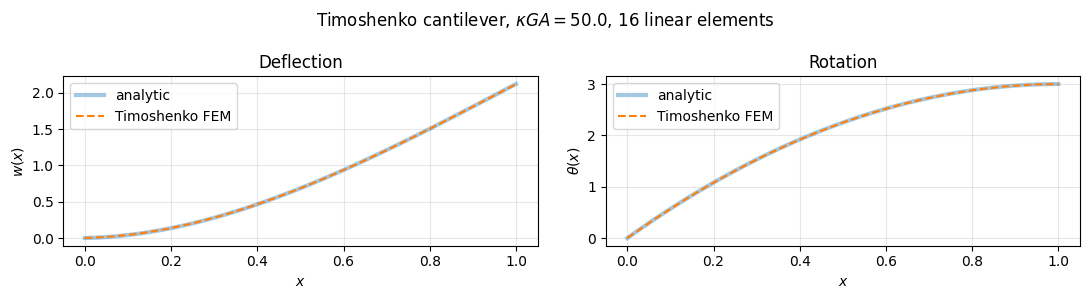

In [6]:
n_elements_plot = 16
space_ts_plot, u_ts_plot = assemble_timoshenko(
    n_elements_plot, kappaGA0, reduced_shear=True
)

x_plot_ts = np.linspace(0, L, 200)
w_vals = u_ts_plot(x_plot_ts)[:, 0]
th_vals = u_ts_plot(x_plot_ts)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(x_plot_ts, w_exact_ts(x_plot_ts, kappaGA0), lw=3, alpha=0.4, label="analytic")
axes[0].plot(x_plot_ts, w_vals, "--", label="Timoshenko FEM")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$w(x)$")
axes[0].set_title("Deflection")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(x_plot_ts, theta_exact_ts(x_plot_ts), lw=3, alpha=0.4, label="analytic")
axes[1].plot(x_plot_ts, th_vals, "--", label="Timoshenko FEM")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel(r"$\theta(x)$")
axes[1].set_title("Rotation")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(
    rf"Timoshenko cantilever, $\kappa GA={kappaGA0}$, {n_elements_plot} linear elements"
)
plt.tight_layout()
plt.show()


### Shear locking

Fix a coarse mesh (`n_elements=4` -- deliberately too coarse to fully resolve
either field) and sweep the shear stiffness $\kappa GA$ from a *thick* beam (shear
and bending comparable) toward a *slender* one ($\kappa GA \gg EI/L^2$, shear
deformation negligible -- the Euler-Bernoulli limit). Track the tip deflection
ratio $w_h(L)/w_\text{exact}(L)$: a healthy discretization should stay near 1
across the whole sweep, since the true solution's *shape* barely changes in the
slender limit -- it just approaches the finite Euler-Bernoulli value, $PL^3/(3EI)$,
as $\kappa GA \to \infty$.

Under full (default, 2-point) integration, the shear energy term $\int \kappa
GA(w'-\theta)^2\,dx$ increasingly penalizes any pointwise mismatch between $w'$ and
$\theta$ as $\kappa GA$ grows -- and with equal-order linear elements, $w'$ is
piecewise-*constant* while $\theta$ is piecewise-*linear*, so they can only match
exactly at isolated points. Full integration enforces $w'\approx\theta$ at both
Gauss points of every element, which over-constrains the coarse linear space and
drives the whole solution toward the trivial (near-zero-deflection) one as
$\kappa GA \to \infty$ -- classical shear locking. Reduced (1-point) integration
only enforces the constraint at each element's own midpoint, leaving enough
freedom in the linear approximation to represent a genuine, if coarse, bending
response -- the standard "selective reduced integration" (SRI) fix.


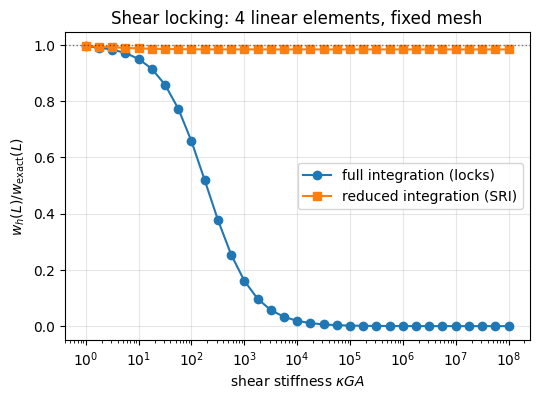

In [7]:
n_elements_lock = 4
kappaGA_sweep = np.logspace(0, 8, 33)

ratio_full = np.zeros_like(kappaGA_sweep)
ratio_reduced = np.zeros_like(kappaGA_sweep)
for i, kGA in enumerate(kappaGA_sweep):
    _, u_full = assemble_timoshenko(n_elements_lock, kGA, reduced_shear=False)
    _, u_red = assemble_timoshenko(n_elements_lock, kGA, reduced_shear=True)
    w_ex_tip = w_exact_ts(np.array([L]), kGA)[0]
    ratio_full[i] = u_full(np.array([L]))[0, 0] / w_ex_tip
    ratio_reduced[i] = u_red(np.array([L]))[0, 0] / w_ex_tip

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.semilogx(kappaGA_sweep, ratio_full, "o-", label="full integration (locks)")
ax.semilogx(kappaGA_sweep, ratio_reduced, "s-", label="reduced integration (SRI)")
ax.axhline(1.0, color="k", lw=1, ls=":", alpha=0.5)
ax.set_xlabel(r"shear stiffness $\kappa GA$")
ax.set_ylabel(r"$w_h(L) / w_\mathrm{exact}(L)$")
ax.set_title(f"Shear locking: {n_elements_lock} linear elements, fixed mesh")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


As $\kappa GA$ grows by eight orders of magnitude, the fully-integrated tip
deflection collapses from essentially exact ($\approx 0.995\times$ the true value at
the thick end of the sweep) to numerically zero ($\approx 10^{-5}\times$ at the
slender end) -- the coarse mesh appears to get *stiffer* as the physical problem
approaches a regime it should handle *more* easily. Reduced integration stays flat
at its fixed (mesh, not slenderness, limited) discretization error the whole way
across, exactly what a locking-free element should do.

This closes out the last piece of the "1D FEM" entry in the tutorial README --
Poisson (`pde.ipynb`, Problem B), Euler-Bernoulli, and now Timoshenko/shear
locking, including the classical failure mode and its standard fix.
